In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_graphviz 
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
from sklearn import tree
from typing import Tuple, List, Optional, Any 


Successfully loaded data from 30_output.csv
Using target column: 'cluster_scenario_1'

--- Feature Selection ---
Features being used for prediction (X) - 252 columns:
['runtime', 'budget', 'country_Afghanistan', 'country_Albania', 'country_Algeria', 'country_AmericanSamoa', 'country_Andorra', 'country_Angola', 'country_Anguilla', 'country_Antarctica', 'country_AntiguaandBarbuda', 'country_Argentina', 'country_Armenia', 'country_Aruba', 'country_Australia'] ...
Target variable being predicted (y): cluster_scenario_1

--- Data Splitting ---
Data split into training (8893 samples) and testing (2224 samples).

--- Model Training ---
Initializing Decision Tree with max_depth=10, random_state=42
Training the model...
Model training complete.

--- Model Evaluation ---
Accuracy on Test Set: 0.4137

Classification Report:
              precision    recall  f1-score   support

           1       0.41      0.71      0.52       750
           2       0.47      0.41      0.44       628
           3

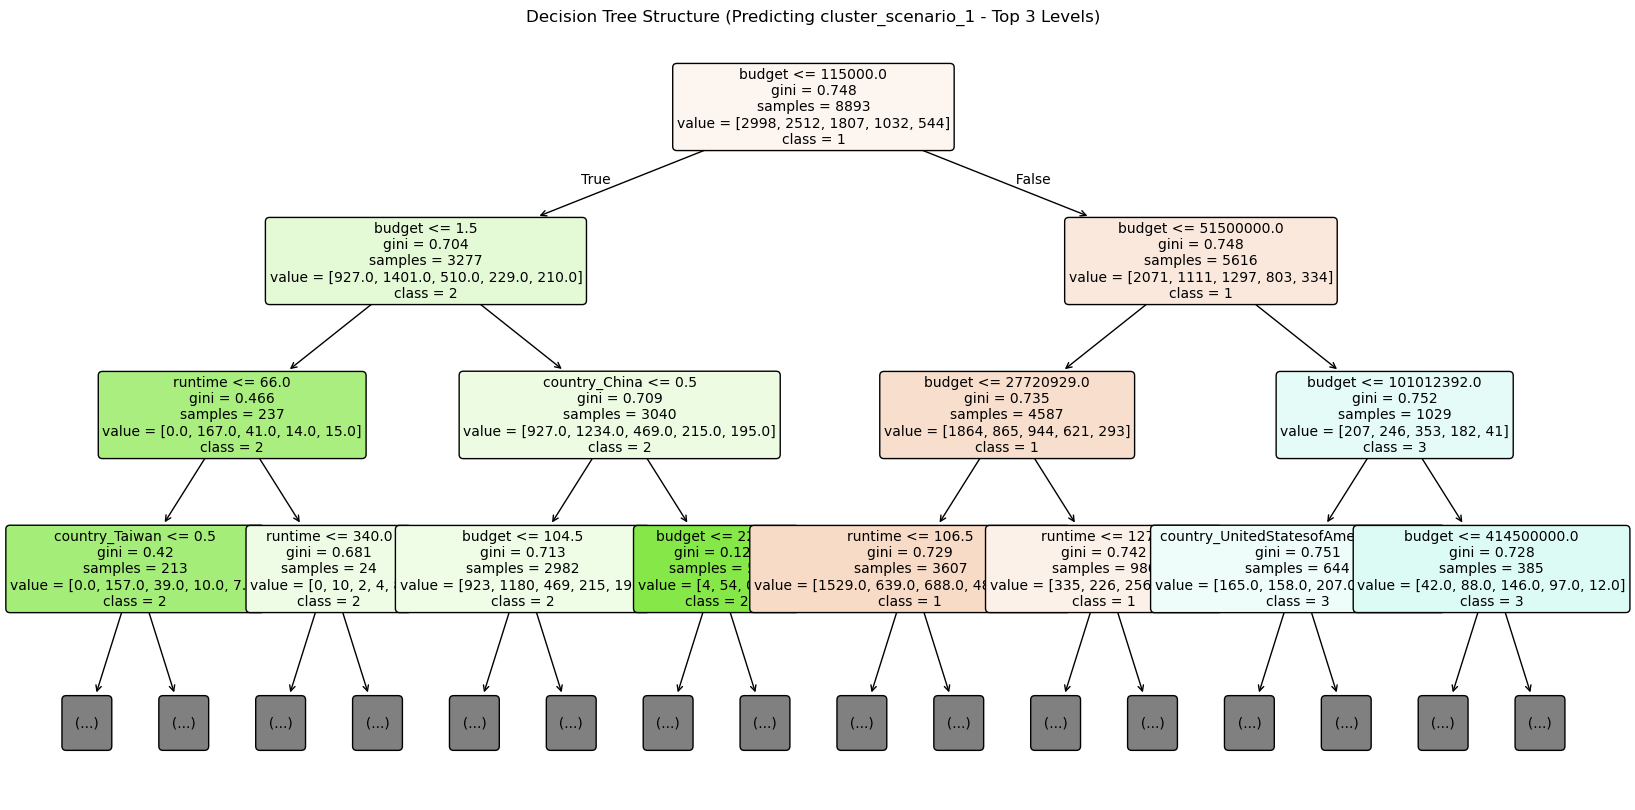

Decision tree visualization generated (showing top 3 levels).

--- Script Finished ---


In [2]:



# --- Configuration Constants ---
DATA_FILE_PATH: str = "30_output.csv"
# Define the target variable (the cluster column you want to predict)
# <<< CHANGE HERE: Set target to cluster_scenario_1 >>>
TARGET_COLUMN: str = 'cluster_scenario_1'
# Define columns to exclude from features
COLUMNS_TO_EXCLUDE: List[str] = [
    'title',
    'vote_average', # Excluded as requested
    'revenue',      # Excluded as requested
    'profitability',# Excluded as requested
    'popularity',   # Excluded as requested
    'vote_count',
    TARGET_COLUMN,  # Cannot use the target as a feature (now cluster_scenario_1)
    # <<< CHANGE HERE: Add cluster_scenario_2 to exclusions >>>
    'cluster_scenario_2', # Exclude the other cluster column
    'release_date', # Identifier/Date
    'overview',     # Text data
    'tagline',      # Text data
    'genres',       # Original categorical (assuming encoded versions exist)
    'production_companies', # Original categorical/complex
    'spoken_languages',     # Original categorical/complex
    'keywords',     # Text data
    # Add any other non-predictive or identifier columns if necessary
]
TEST_SET_SIZE: float = 0.20  # Proportion of data to use for testing (20%)
RANDOM_SEED: int = 42       # Ensures reproducibility for splitting and model training
TREE_MAX_DEPTH: Optional[int] = 10 # Max depth for Decision Tree (controls complexity)
VISUALIZE_MAX_DEPTH: int = 3 # Max depth to show in the visualization for readability

# --- Function Definitions ---

def load_data(file_path: str) -> Optional[pd.DataFrame]:
    """
    Loads the dataset from a CSV file.

    Args:
        file_path (str): The path to the CSV file.

    Returns:
        Optional[pd.DataFrame]: A pandas DataFrame containing the loaded data,
                                 or None if loading fails.
    """
    try:
        df = pd.read_csv(file_path)
        print(f"Successfully loaded data from {file_path}")
        return df
    except FileNotFoundError:
        print(f"Error: File not found at {file_path}. Make sure the file exists.")
        return None
    except Exception as e:
        print(f"Error loading CSV file {file_path}: {e}")
        return None

def find_target_column(df: pd.DataFrame, preferred_target: str) -> Optional[str]:
    """
    Checks if the preferred target column exists.
    (Note: Simplified as we are now explicitly setting the target)

    Args:
        df (pd.DataFrame): The input DataFrame.
        preferred_target (str): The name for the target column.

    Returns:
        Optional[str]: The name of the target column if it exists, or None.
    """
    if preferred_target in df.columns:
        print(f"Using target column: '{preferred_target}'")
        return preferred_target
    else:
        print(f"Error: Target column '{preferred_target}' not found in DataFrame.")
        return None


def prepare_features(df: pd.DataFrame, target_col: str, exclude_cols: List[str]) -> Optional[Tuple[pd.DataFrame, pd.Series]]:
    """
    Prepares the feature matrix (X) and target vector (y) by selecting relevant columns.

    Args:
        df (pd.DataFrame): The input DataFrame.
        target_col (str): The name of the target column.
        exclude_cols (List[str]): A list of column names to exclude from the features.

    Returns:
        Optional[Tuple[pd.DataFrame, pd.Series]]: A tuple containing the features (X)
                                                  and target (y), or None if preparation fails.
    """
    # Ensure the target column exists
    if target_col not in df.columns:
         print(f"Error: Target column '{target_col}' specified but not found in DataFrame.")
         return None

    # Filter out exclusion columns that might not exist in the DataFrame to avoid errors
    # Also ensure the target column itself is in the exclusion list for X
    actual_exclude_cols = [col for col in exclude_cols if col in df.columns]
    if target_col not in actual_exclude_cols:
         actual_exclude_cols.append(target_col)

    # Select features (X) and target (y)
    X = df.drop(columns=actual_exclude_cols)
    y = df[target_col]

    # Ensure all feature columns are numeric
    # Note: This assumes categorical features were already encoded as numbers in the CSV.
    X = X.select_dtypes(include=['number'])

    print("\n--- Feature Selection ---")
    print(f"Features being used for prediction (X) - {X.shape[1]} columns:")
    # Print only first few column names if list is very long
    if X.shape[1] > 15:
         print(list(X.columns[:15]), "...")
    else:
         print(list(X.columns))
    print(f"Target variable being predicted (y): {target_col}")

    if X.shape[1] == 0:
        print("\nError: No feature columns remaining after exclusions. Cannot train the model.")
        return None

    return X, y

def train_decision_tree(X_train: pd.DataFrame, y_train: pd.Series, max_depth: Optional[int], random_state: int) -> DecisionTreeClassifier:
    """
    Initializes and trains a Decision Tree Classifier.

    Args:
        X_train (pd.DataFrame): Training features.
        y_train (pd.Series): Training target labels.
        max_depth (Optional[int]): Maximum depth of the tree. None means nodes are expanded until
                                   all leaves are pure or contain less than min_samples_split samples.
        random_state (int): Seed for reproducibility.

    Returns:
        DecisionTreeClassifier: The trained model.
    """
    print("\n--- Model Training ---")
    print(f"Initializing Decision Tree with max_depth={max_depth}, random_state={random_state}")
    dt_classifier = DecisionTreeClassifier(max_depth=max_depth, random_state=random_state)

    print("Training the model...")
    dt_classifier.fit(X_train, y_train)
    print("Model training complete.")
    return dt_classifier

def evaluate_model(model: DecisionTreeClassifier, X_test: pd.DataFrame, y_test: pd.Series) -> None:
    """
    Evaluates the trained model on the test set and prints metrics.

    Args:
        model (DecisionTreeClassifier): The trained decision tree model.
        X_test (pd.DataFrame): Test features.
        y_test (pd.Series): Test target labels.
    """
    print("\n--- Model Evaluation ---")
    # Predict on the test set
    y_pred = model.predict(X_test)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    # Ensure target_names are consistent with the actual labels in y_test/y_pred
    unique_labels = sorted(y_test.unique())
    target_names = [str(label) for label in unique_labels]
    report = classification_report(y_test, y_pred, target_names=target_names, zero_division=0)

    print(f"Accuracy on Test Set: {accuracy:.4f}")
    print("\nClassification Report:")
    print(report)

def visualize_tree(model: DecisionTreeClassifier, feature_names: List[str], class_names: List[str], max_depth_plot: int) -> None:
    """
    Generates and displays a visualization of the decision tree (top levels).

    Args:
        model (DecisionTreeClassifier): The trained decision tree model.
        feature_names (List[str]): Names of the feature columns.
        class_names (List[str]): Names of the target classes (clusters).
        max_depth_plot (int): The maximum depth of the tree to display in the plot.
    """
    print("\n--- Tree Visualization ---")
    try:
        plt.figure(figsize=(20, 10)) # Adjust size as needed
        tree.plot_tree(model,
                       feature_names=feature_names,
                       class_names=class_names, # Use provided class names
                       filled=True,
                       rounded=True,
                       max_depth=max_depth_plot, # Limit plot depth
                       fontsize=10)
        plt.title(f"Decision Tree Structure (Predicting {TARGET_COLUMN} - Top {max_depth_plot} Levels)")
        # plt.savefig("decision_tree.png") # Uncomment to save the plot to a file
        plt.show()
        print(f"Decision tree visualization generated (showing top {max_depth_plot} levels).")
    except Exception as e:
        print(f"Could not generate tree visualization: {e}")
        print("Ensure matplotlib and scikit-learn are correctly installed.")
        print("If using a system without a GUI, saving the plot to a file might be necessary.")


# --- Main Execution ---

if __name__ == "__main__":
    # 1. Load Data
    df_raw = load_data(DATA_FILE_PATH)

    if df_raw is not None:
        # 1b. Verify the target column exists
        actual_target_column = find_target_column(df_raw, TARGET_COLUMN)

        if actual_target_column:
             # 2. Prepare Features and Target
             # Pass the explicitly set TARGET_COLUMN and updated COLUMNS_TO_EXCLUDE
             prepared_data = prepare_features(df_raw, actual_target_column, COLUMNS_TO_EXCLUDE)

             if prepared_data is not None:
                  X, y = prepared_data

                  # 3. Split Data into Training and Testing sets
                  print("\n--- Data Splitting ---")
                  X_train, X_test, y_train, y_test = train_test_split(
                       X, y,
                       test_size=TEST_SET_SIZE,
                       random_state=RANDOM_SEED,
                       stratify=y # Helps maintain cluster proportions in train/test sets
                  )
                  print(f"Data split into training ({X_train.shape[0]} samples) and testing ({X_test.shape[0]} samples).")

                  # 4. Train the Decision Tree Model
                  model = train_decision_tree(X_train, y_train, max_depth=TREE_MAX_DEPTH, random_state=RANDOM_SEED)

                  # 5. Evaluate the Model
                  evaluate_model(model, X_test, y_test)

                  # 6. Visualize the Tree (Optional)
                  # Get unique class labels from the actual target column 'y' and sort them
                  class_labels = sorted(y.unique())
                  # Convert class names to strings for plotting
                  class_names_str = [str(c) for c in class_labels]
                  visualize_tree(model,
                                 feature_names=list(X.columns),
                                 class_names=class_names_str,
                                 max_depth_plot=VISUALIZE_MAX_DEPTH)
                  print("\n--- Script Finished ---")

Successfully loaded data from 30_output.csv
Using target column: 'cluster_scenario_1'

--- Feature Selection ---
Features being used for prediction (X) - 252 columns:
['runtime', 'budget', 'country_Afghanistan', 'country_Albania', 'country_Algeria', 'country_AmericanSamoa', 'country_Andorra', 'country_Angola', 'country_Anguilla', 'country_Antarctica', 'country_AntiguaandBarbuda', 'country_Argentina', 'country_Armenia', 'country_Aruba', 'country_Australia'] ...
Target variable being predicted (y): cluster_scenario_1

--- Data Splitting ---
Data split into training (8893 samples) and testing (2224 samples).

--- Model Training ---
Initializing Decision Tree with max_depth=None, random_state=42
Training the model...
Model training complete.

--- Model Evaluation ---
Accuracy on Test Set: 0.3498

Classification Report:
              precision    recall  f1-score   support

           1       0.41      0.48      0.44       750
           2       0.41      0.43      0.42       628
          

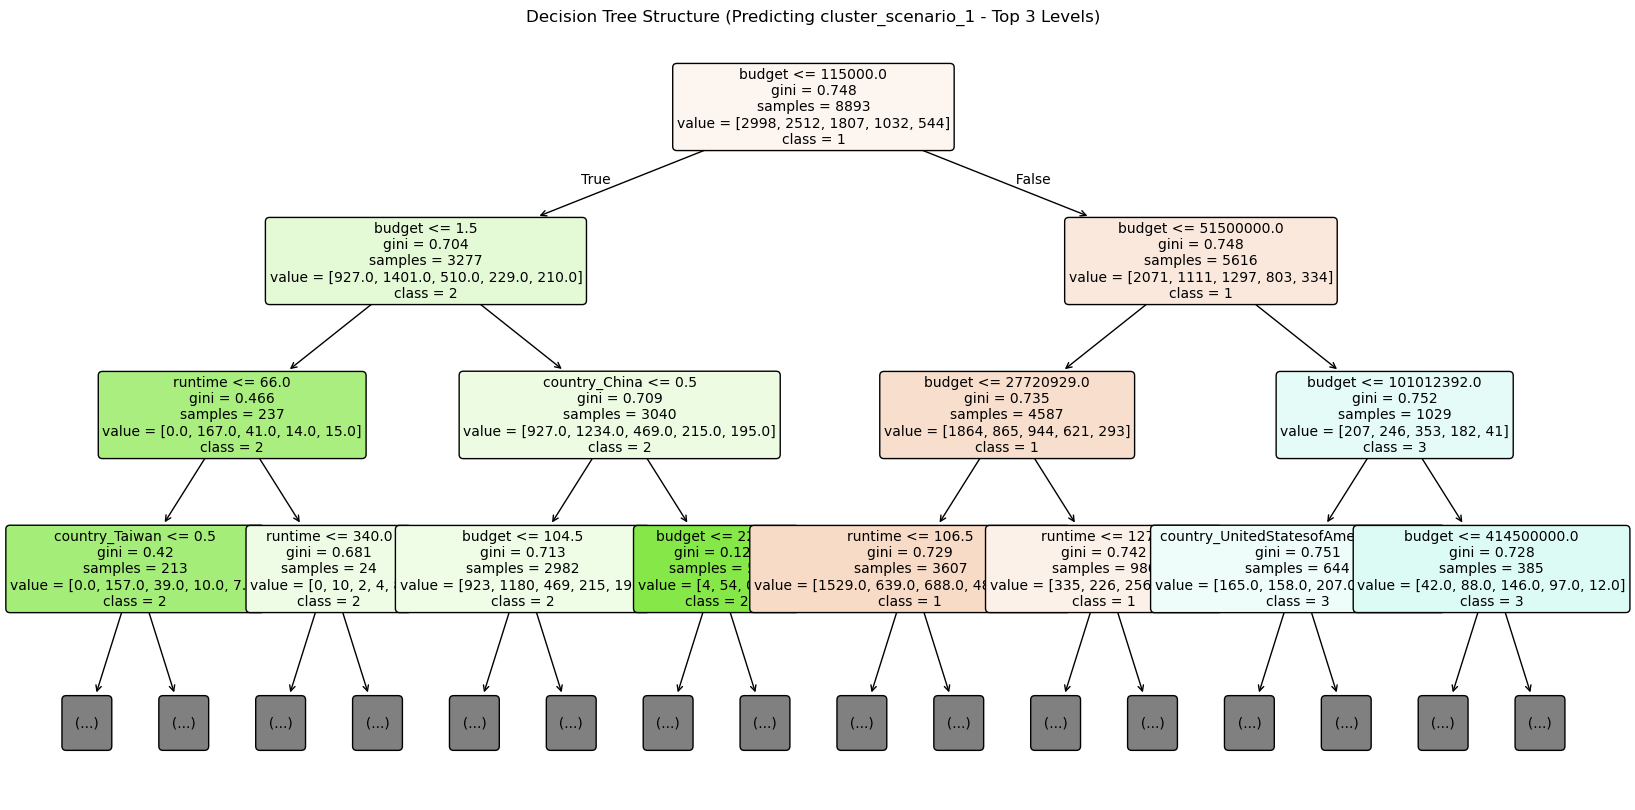

Matplotlib visualization generated (showing top 3 levels).

--- Exporting Tree to Graphviz .dot format ---
Successfully generated .dot data for the full tree.

--- Instructions for Visualization ---
1. Copy the entire block of text starting from 'digraph Tree {' below and ending with '}'.
2. Save this text content into a file named 'full_decision_tree_cluster_scenario_1.dot'.
3. **Install Graphviz:** If you don't have it, download and install it from https://graphviz.org/download/
4. **Convert using Command Line:** Open a terminal or command prompt, navigate to the directory where you saved 'full_decision_tree_cluster_scenario_1.dot', and run one of these commands:
   - For SVG (recommended, view in browser): dot -Tsvg full_decision_tree_cluster_scenario_1.dot -o full_decision_tree_cluster_scenario_1.svg
   - For PNG: dot -Tpng full_decision_tree_cluster_scenario_1.dot -o full_decision_tree_cluster_scenario_1.png
   - For PDF: dot -Tpdf full_decision_tree_cluster_scenario_1.dot -o full

In [3]:


# --- Configuration Constants ---
DATA_FILE_PATH: str = "30_output.csv"
TARGET_COLUMN: str = 'cluster_scenario_1' # Predicting scenario 1
COLUMNS_TO_EXCLUDE: List[str] = [
    'title', 'vote_average', 'revenue', 'profitability', 'popularity', 'vote_count', 
    TARGET_COLUMN, 'cluster_scenario_2', 'release_date', 'overview', 'tagline',
    'genres', 'production_companies', 'spoken_languages', 'keywords',
]
TEST_SET_SIZE: float = 0.20
RANDOM_SEED: int = 42
# Set TREE_MAX_DEPTH to None if you want the tree to grow fully for the export
TREE_MAX_DEPTH: Optional[int] = None # Allow full tree growth for detailed export
VISUALIZE_MAX_DEPTH: int = 3 # Keep matplotlib preview shallow

# --- Function Definitions ---
# (load_data, find_target_column, prepare_features, train_decision_tree,
#  evaluate_model, visualize_tree remain the same as previous version - OMITTED FOR BREVITY)

def load_data(file_path: str) -> Optional[pd.DataFrame]:
    """Loads the dataset from a CSV file."""
    try:
        df = pd.read_csv(file_path)
        print(f"Successfully loaded data from {file_path}")
        return df
    except FileNotFoundError:
        print(f"Error: File not found at {file_path}. Make sure the file exists.")
        return None
    except Exception as e:
        print(f"Error loading CSV file {file_path}: {e}")
        return None

def find_target_column(df: pd.DataFrame, preferred_target: str) -> Optional[str]:
    """Checks if the preferred target column exists."""
    if preferred_target in df.columns:
        print(f"Using target column: '{preferred_target}'")
        return preferred_target
    else:
        print(f"Error: Target column '{preferred_target}' not found in DataFrame.")
        return None

def prepare_features(df: pd.DataFrame, target_col: str, exclude_cols: List[str]) -> Optional[Tuple[pd.DataFrame, pd.Series]]:
    """Prepares the feature matrix (X) and target vector (y)."""
    if target_col not in df.columns:
         print(f"Error: Target column '{target_col}' specified but not found in DataFrame.")
         return None
    actual_exclude_cols = [col for col in exclude_cols if col in df.columns]
    if target_col not in actual_exclude_cols:
         actual_exclude_cols.append(target_col)
    X = df.drop(columns=actual_exclude_cols)
    y = df[target_col]
    X = X.select_dtypes(include=['number'])
    print("\n--- Feature Selection ---")
    print(f"Features being used for prediction (X) - {X.shape[1]} columns:")
    if X.shape[1] > 15:
         print(list(X.columns[:15]), "...")
    else:
         print(list(X.columns))
    print(f"Target variable being predicted (y): {target_col}")
    if X.shape[1] == 0:
        print("\nError: No feature columns remaining after exclusions. Cannot train the model.")
        return None
    return X, y

def train_decision_tree(X_train: pd.DataFrame, y_train: pd.Series, max_depth: Optional[int], random_state: int) -> DecisionTreeClassifier:
    """Initializes and trains a Decision Tree Classifier."""
    print("\n--- Model Training ---")
    print(f"Initializing Decision Tree with max_depth={max_depth}, random_state={random_state}")
    dt_classifier = DecisionTreeClassifier(max_depth=max_depth, random_state=random_state)
    print("Training the model...")
    dt_classifier.fit(X_train, y_train)
    print("Model training complete.")
    return dt_classifier

def evaluate_model(model: DecisionTreeClassifier, X_test: pd.DataFrame, y_test: pd.Series) -> None:
    """Evaluates the trained model on the test set and prints metrics."""
    print("\n--- Model Evaluation ---")
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    unique_labels = sorted(y_test.unique())
    target_names = [str(label) for label in unique_labels]
    report = classification_report(y_test, y_pred, target_names=target_names, zero_division=0)
    print(f"Accuracy on Test Set: {accuracy:.4f}")
    print("\nClassification Report:")
    print(report)

def visualize_tree(model: DecisionTreeClassifier, feature_names: List[str], class_names: List[str], max_depth_plot: int) -> None:
    """Generates and displays a visualization of the decision tree (top levels using matplotlib)."""
    print("\n--- Matplotlib Tree Visualization (Top Levels) ---")
    try:
        plt.figure(figsize=(20, 10))
        tree.plot_tree(model,
                       feature_names=feature_names,
                       class_names=class_names,
                       filled=True,
                       rounded=True,
                       max_depth=max_depth_plot, # Limit plot depth for preview
                       fontsize=10)
        plt.title(f"Decision Tree Structure (Predicting {TARGET_COLUMN} - Top {max_depth_plot} Levels)")
        plt.show()
        print(f"Matplotlib visualization generated (showing top {max_depth_plot} levels).")
    except Exception as e:
        print(f"Could not generate matplotlib visualization: {e}")

# <<< NEW FUNCTION >>>
def export_tree_graphviz(model: DecisionTreeClassifier, feature_names: List[str], class_names: List[str], output_file_base: str = "decision_tree") -> None:
    """
    Exports the decision tree to a .dot file format and prints instructions
    for converting it using Graphviz.

    Args:
        model (DecisionTreeClassifier): The trained decision tree model.
        feature_names (List[str]): Names of the feature columns.
        class_names (List[str]): Names of the target classes (clusters).
        output_file_base (str): The base name for the output .dot file.
    """
    print(f"\n--- Exporting Tree to Graphviz .dot format ---")
    dot_file_name = f"{output_file_base}.dot"
    try:
        dot_data = export_graphviz(model,
                                   out_file=None, # Output directly to string/variable
                                   feature_names=feature_names,
                                   class_names=class_names,
                                   filled=True,
                                   rounded=True,
                                   special_characters=True) # Handles special characters in names

        # Print the .dot data to the console. The user can copy this.
        print(f"Successfully generated .dot data for the full tree.")
        print(f"\n--- Instructions for Visualization ---")
        print(f"1. Copy the entire block of text starting from 'digraph Tree {{' below and ending with '}}'.")
        print(f"2. Save this text content into a file named '{dot_file_name}'.")
        print(f"3. **Install Graphviz:** If you don't have it, download and install it from https://graphviz.org/download/")
        print(f"4. **Convert using Command Line:** Open a terminal or command prompt, navigate to the directory where you saved '{dot_file_name}', and run one of these commands:")
        print(f"   - For SVG (recommended, view in browser): dot -Tsvg {dot_file_name} -o {output_file_base}.svg")
        print(f"   - For PNG: dot -Tpng {dot_file_name} -o {output_file_base}.png")
        print(f"   - For PDF: dot -Tpdf {dot_file_name} -o {output_file_base}.pdf")
        print(f"5. Open the generated .svg, .png, or .pdf file to view the entire tree.")
        print(f"\n--- Start of .dot File Content ---")
        print(dot_data)
        print(f"--- End of .dot File Content ---")

    except Exception as e:
        print(f"Error exporting tree to .dot format: {e}")


# --- Main Execution ---

if __name__ == "__main__":
    # 1. Load Data
    df_raw = load_data(DATA_FILE_PATH)

    if df_raw is not None:
        # 1b. Verify the target column exists
        actual_target_column = find_target_column(df_raw, TARGET_COLUMN)

        if actual_target_column:
             # 2. Prepare Features and Target
             prepared_data = prepare_features(df_raw, actual_target_column, COLUMNS_TO_EXCLUDE)

             if prepared_data is not None:
                  X, y = prepared_data

                  # 3. Split Data into Training and Testing sets
                  print("\n--- Data Splitting ---")
                  X_train, X_test, y_train, y_test = train_test_split(
                       X, y,
                       test_size=TEST_SET_SIZE,
                       random_state=RANDOM_SEED,
                       stratify=y
                  )
                  print(f"Data split into training ({X_train.shape[0]} samples) and testing ({X_test.shape[0]} samples).")

                  # 4. Train the Decision Tree Model
                  # Make sure TREE_MAX_DEPTH is suitable (e.g., None for full tree export)
                  model = train_decision_tree(X_train, y_train, max_depth=TREE_MAX_DEPTH, random_state=RANDOM_SEED)

                  # 5. Evaluate the Model
                  evaluate_model(model, X_test, y_test)

                  # Get class names for visualizations
                  class_labels = sorted(y.unique())
                  class_names_str = [str(c) for c in class_labels]

                  # 6. Visualize Tree (Matplotlib Preview - Optional)
                  visualize_tree(model,
                                 feature_names=list(X.columns),
                                 class_names=class_names_str,
                                 max_depth_plot=VISUALIZE_MAX_DEPTH)

                  # <<< NEW STEP: Export full tree using Graphviz >>>
                  # 7. Export Tree for Full Visualization
                  export_tree_graphviz(model,
                                       feature_names=list(X.columns),
                                       class_names=class_names_str,
                                       output_file_base=f"full_decision_tree_{TARGET_COLUMN}") # Name output based on target


                  print("\n--- Script Finished ---")